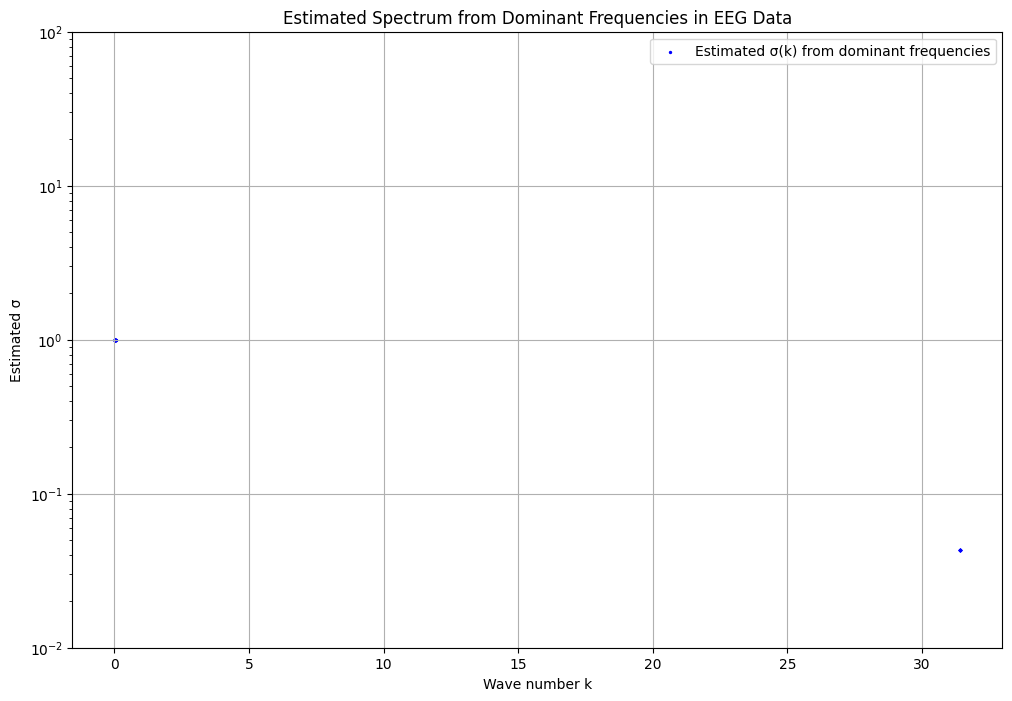

In [2]:
import numpy as np
import os
from scipy.special import lambertw
import matplotlib.pyplot as plt

# Define directories
base_dir = '/home/vincent/MySSD/JupyterProjects/AAA_projects/UnlimitedResearchCooperative/Synthetic_Intelligence_Labs/EEG_Chaos_Kuramoto_Neural_Net'
EEG_data_path = os.path.join(base_dir, 'eeg_data_with_channels.npy')
EEG_data = np.load(EEG_data_path, allow_pickle=True)

sampling_rate = 1000  # Hz
start_time, end_time = 814.571, 921.515  # Data without stimulation occurring
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)
EEG_data_segment = EEG_data[start_index:end_index, :]

# Define function to identify dominant frequencies
def identify_dominant_frequencies(eeg_data, sampling_rate, num_frequencies=5):
    all_freqs = []
    for channel_data in eeg_data.T:  # Iterate through each channel
        fft_result = np.fft.fft(channel_data)
        frequencies = np.fft.fftfreq(len(channel_data), 1/sampling_rate)
        spectrum_magnitude = np.abs(fft_result)
        dominant_freqs = frequencies[np.argsort(spectrum_magnitude)[-num_frequencies:]]  # Top frequencies
        all_freqs.extend(dominant_freqs)
    return np.array(all_freqs)

# Define function to estimate k and sigma values
def estimate_k_sigma(dominant_freqs, v=1.0):
    k_values = 2 * np.pi * np.array(dominant_freqs) / v
    sigma_values = np.exp(-0.1 * k_values)  
    return k_values, sigma_values

# Call the function to identify dominant frequencies
dominant_freqs = identify_dominant_frequencies(EEG_data_segment, sampling_rate)

# Consider only positive frequencies
dominant_freqs = dominant_freqs[dominant_freqs > 0]

v = 6.0  # Example value for propagation velocity in m/s, adjust based on your model

# Calculate k and sigma values using a revised approach
k_values, sigma_values = estimate_k_sigma(dominant_freqs, v)

# Filter out any unreasonable k values, if necessary, by applying a domain-specific threshold
k_values = k_values[np.abs(k_values) < 100]  # Example threshold, adjust as needed
sigma_values = sigma_values[:len(k_values)]  # Ensure sigma_values matches k_values length

# Now plot with a more appropriate range and scale
plt.figure(figsize=(12, 8))
plt.scatter(k_values, sigma_values, color='blue', s=2, label='Estimated σ(k) from dominant frequencies')
plt.xlabel('Wave number k')
plt.ylabel('Estimated σ')
plt.title('Estimated Spectrum from Dominant Frequencies in EEG Data')
plt.legend()
plt.grid(True)
plt.yscale('log')  # Use a logarithmic scale for sigma if the values vary widely
plt.ylim([1e-2, 1e2])  # Set limits for y-axis to reasonable values for visualization
plt.show()

### Welch's PSD and PSD from FFT

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define directories
base_dir = '/home/vincent/MySSD/JupyterProjects/AAA_projects/UnlimitedResearchCooperative/Synthetic_Intelligence_Labs/EEG_Chaos_Kuramoto_Neural_Net'
EEG_data_path = os.path.join(base_dir, 'eeg_data_with_channels.npy')
EEG_data = np.load(EEG_data_path, allow_pickle=True)

# Define the sampling frequency and other parameters
fs = 1000

# Define the timepoints for the start and stop of each stimulation
# Extracted from your provided times - adjust indices as per your data structure
stim_times = [
    (654746.0, 770515.0),
    (805571.0, 921515.0),
    (2156695.0, 2272756.0),
    (2307798.0, 3019822.0)
]

# Initialize a dictionary to store EEG segments post-stimulation
post_stim_segments = {}

for i, (stim_stop, stim_start) in enumerate(stim_times):
    start_index, end_index = int(stim_stop * (fs/1000)), int(stim_start * (fs/1000))
    # Assuming EEG_data is a NumPy array with shape (timepoints, channels)
    eeg_segment = EEG_data[start_index:end_index, :]
    post_stim_segments[f'segment_{i}'] = eeg_segment
# EEG channel names
eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6', 'P7',
    'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# Initialize dictionaries to store PSD values for each channel
welch_psd_data = {}
fft_psd_data = {}

# Loop through each EEG channel to calculate PSD using both Welch's method and FFT
for i, channel in enumerate(eeg_channels):
    # Select EEG data from the current channel
    eeg_data = EEG_data[:, i]
    
    # Use Welch's method to estimate the power spectral density
    welch_frequencies, welch_psd = signal.welch(eeg_data, fs, nperseg=1024)
    welch_psd_data[channel] = welch_psd
    
    # Compute the FFT and then calculate the PSD
    fft_result = np.fft.fft(eeg_data)
    fft_psd = np.abs(fft_result) ** 2 / len(eeg_data)
    fft_frequencies = np.fft.fftfreq(len(eeg_data), d=1/fs)
    fft_psd_data[channel] = fft_psd

# Plotting the Welch PSD data
plt.figure(figsize=(15, 24))
for i, channel in enumerate(eeg_channels):
    plt.subplot(len(eeg_channels), 1, i+1)
    plt.semilogy(welch_frequencies, welch_psd_data[channel])
    plt.title(f'Welch PSD - EEG Channel {channel}')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('PSD [V**2/Hz]')
    plt.grid(True)
plt.tight_layout()
plt.show()

# Plotting the FFT PSD data
plt.figure(figsize=(15, 24))
for i, channel in enumerate(eeg_channels):
    # Plot only positive frequencies
    positive_freqs = fft_frequencies > 0
    plt.subplot(len(eeg_channels), 1, i+1)
    plt.semilogy(fft_frequencies[positive_freqs], fft_psd_data[channel][positive_freqs])
    plt.title(f'FFT PSD - EEG Channel {channel}')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('PSD [V**2]')
    plt.grid(True)
plt.tight_layout()
plt.show()

# Save the Welch PSD data as a numpy array
welch_save_path = '/path/to/welch_psd_data.npy'
np.save(welch_save_path, welch_psd_data)

# Save the FFT PSD data for all channels as a numpy file
fft_save_path = '/path/to/fft_psd_data.npy'
np.save(fft_save_path, fft_psd_data)

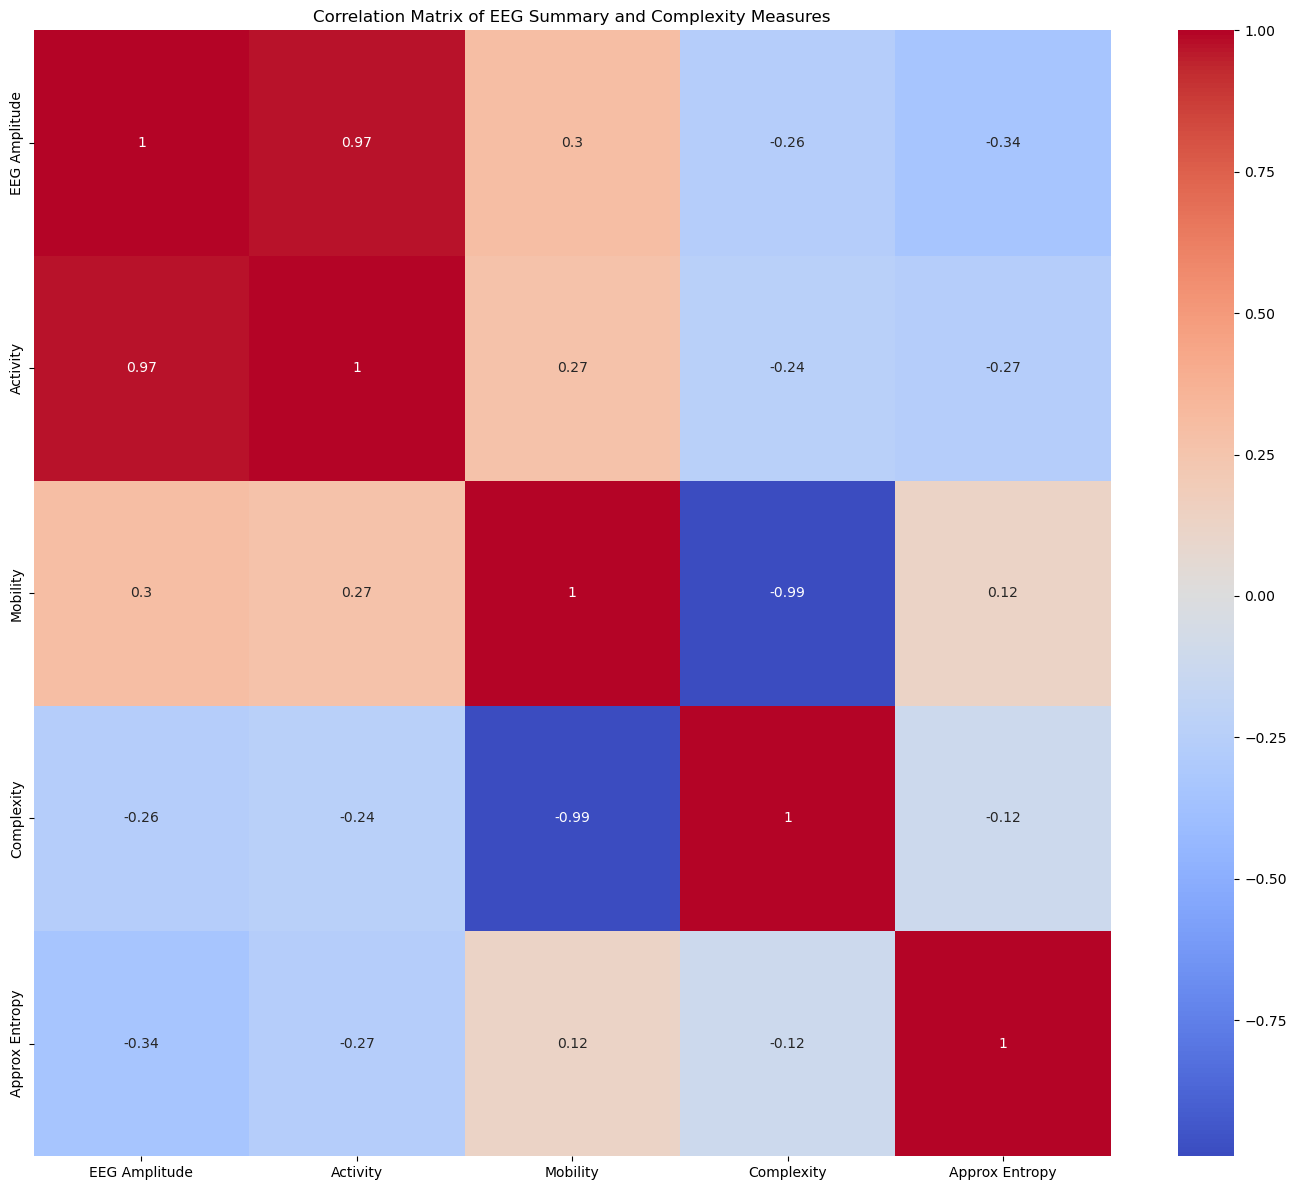

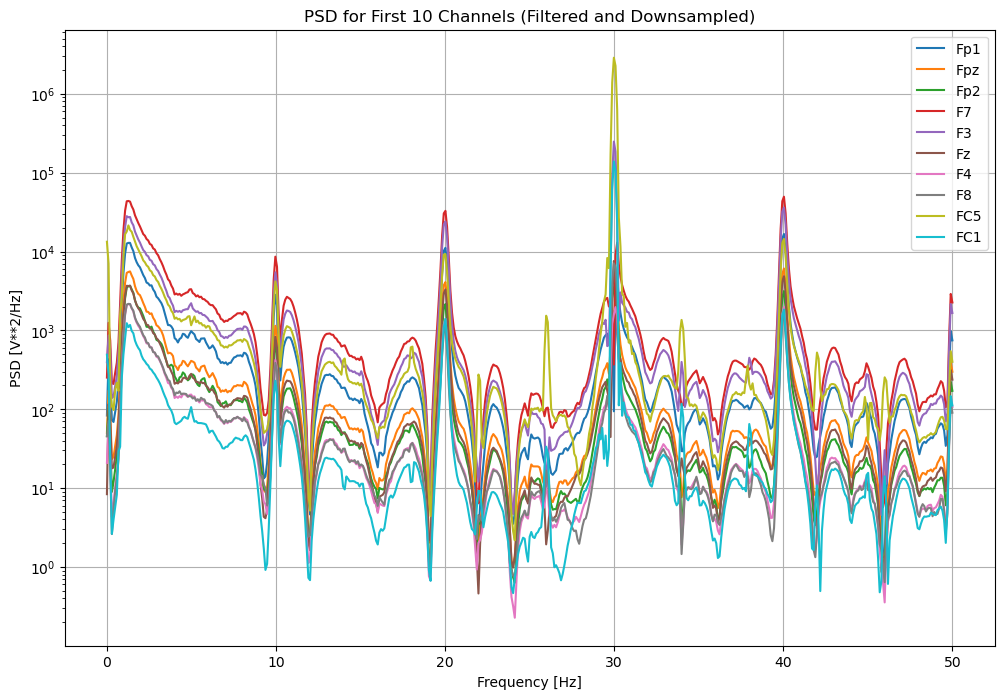

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch

# Assuming filtered_downsampled_data and complexity_measures are already defined

# Create arrays for EEG data and complexity measures
eeg_data = np.array([filtered_downsampled_data[ch] for ch in eeg_channel_names])
activity = np.array([complexity_measures[ch]['Activity'] for ch in eeg_channel_names])
mobility = np.array([complexity_measures[ch]['Mobility'] for ch in eeg_channel_names])
complexity = np.array([complexity_measures[ch]['Complexity'] for ch in eeg_channel_names])
approx_entropy = np.array([complexity_measures[ch]['Approx Entropy'] for ch in eeg_channel_names])

# Compute a summary statistic for each EEG channel (e.g., mean amplitude)
eeg_summary = np.mean(np.abs(eeg_data), axis=1)

# Combine all measures
all_measures = np.vstack([eeg_summary, activity, mobility, complexity, approx_entropy]).T

# Compute the correlation matrix
correlation_matrix = np.corrcoef(all_measures.T)

# Plot combined correlation matrix
plt.figure(figsize=(14, 12))
combined_labels = ['EEG Amplitude'] + ['Activity', 'Mobility', 'Complexity', 'Approx Entropy']
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', 
            xticklabels=combined_labels, yticklabels=combined_labels)
plt.title('Correlation Matrix of EEG Summary and Complexity Measures')
plt.tight_layout()
plt.show()

# Plot PSD for all channels (without harmonics)
plt.figure(figsize=(12, 8))
for i, (channel_name, data) in enumerate(filtered_downsampled_data.items()):
    if i < 10:  # Plot only the first 10 channels
        frequencies, psd = welch(data, fs/downsampling_factor, nperseg=1024)
        plt.semilogy(frequencies, psd, label=channel_name)
    else:
        break

plt.title('PSD for First 10 Channels (Filtered and Downsampled)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [V**2/Hz]')
plt.legend()
plt.grid(True)
plt.show()

Topological Data Analysis

Persistent Homology





Minimum Norm Estimates

Beamforming

Quantum Mechanics Inspired

Modified Quantum Stochastic Processes

Modified Quantum Field Theory




Complex Systems and Network Analysis





Signal Processing Techniques

Hilbert-Huang Transform

Wavelet Coherence



Cognitive and Computational Neuroscience





Additional Concepts



Cartesian coordinates
Circular coordinates
Impulse response
Continuous-time LTI system
Haar measure
Differential entropy
Diffeomorphism
Banach space
Fréchet space


### Modified Spearmans

In [6]:
import numpy as np
import scipy.stats as stats

def modified_spearman_rank_correlation(X, Y):
    """
    Compute the modified Spearman's rank correlation coefficient for X and Y,
    with special handling for ties as described.
    
    Parameters:
    X (array-like): A list or array of observations.
    Y (array-like): A list or array of observations, same length as X.
    
    Returns:
    float: The computed Spearman's rank correlation coefficient.
    """
    # Convert inputs to numpy arrays
    X, Y = np.array(X), np.array(Y)
    
    # Calculate the ranks for X and Y
    ranks_X = stats.rankdata(X, method='average')
    ranks_Y = stats.rankdata(Y, method='average')
    
    # Randomly sort ties in Y
    sorted_indices = np.random.permutation(len(Y))
    ranks_Y = ranks_Y[sorted_indices]
    ranks_X = ranks_X[sorted_indices]
    
    # Calculate the rank differences and their squared differences
    rank_diff = ranks_X - ranks_Y
    rank_diff_squared = rank_diff**2
    
    # Calculate the Spearman's rank correlation coefficient
    n = len(X)
    numerator = 6 * np.sum(rank_diff_squared)
    denominator = n * (n**2 - 1)
    rho = 1 - (numerator / denominator)
    
    return rho

# Example data
X = np.random.rand(10)
Y = np.random.rand(10)

# Calculate the modified Spearman's rank correlation coefficient
modified_rho = modified_spearman_rank_correlation(X, Y)
modified_rho

-0.1393939393939394

### Bernoulli scheme

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>This analysis uses the Bernoulli scheme to convert EEG data into a binary format, allowing for the calculation of the probability of events (1s) in the binary data. This method provides a statistical view of the EEG signals across different channels.</p>
        <h2>Data Preparation</h2>
        <p>The EEG data is segmented to exclude periods of stimulation, ensuring that the analysis focuses on natural brain activity.</p>
        <p><strong>Formula:</strong></p>
        \[
        \text{Segment indices} = [\text{start\_index}, \text{end\_index}]
        \]
        where \(\text{start\_index} = \text{start\_time} \times \text{sampling\_rate}\) and \(\text{end\_index} = \text{end\_time} \times \text{sampling\_rate}\).</p>
        <h2>Binary Conversion</h2>
        <p>The EEG data is converted to a binary format using a threshold based on the mean and standard deviation of the data.</p>
        <p><strong>Formula:</strong></p>
        \[
        \text{Binary EEG Data} = \begin{cases}
        1 & \text{if } \text{EEG Data} > \mu + \sigma \\
        0 & \text{otherwise}
        \end{cases}
        \]
        where \(\mu\) is the mean and \(\sigma\) is the standard deviation of the EEG data.</p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Probability Calculation</h2>
        <p>The probability of events (1s) is calculated for each EEG channel, providing a measure of the occurrence of high-amplitude signals.</p>
        <p><strong>Formula:</strong></p>
        \[
        P(\text{Event}) = \frac{\sum \text{Binary EEG Data}}{N}
        \]
        where \(N\) is the total number of samples for each channel.</p>
        <h2>Visualization</h2>
        <p>The probabilities are visualized using a bar plot, showing the probability of events for each EEG channel.</p>
        <h2>Steps:</h2>
        <ul>
            <li>Convert the EEG data to binary format using the specified threshold.</li>
            <li>Calculate the probability of events (1s) for each channel.</li>
            <li>Plot the probabilities for each EEG channel to visualize the distribution of high-amplitude events.</li>
        </ul>
        <h2>Conclusion</h2>
        <p>This methodology provides a statistical analysis of EEG data by converting it to a binary format and calculating the probability of events. The visualization of these probabilities offers insights into the distribution of high-amplitude signals across different channels.</p>
    </div>
</div>


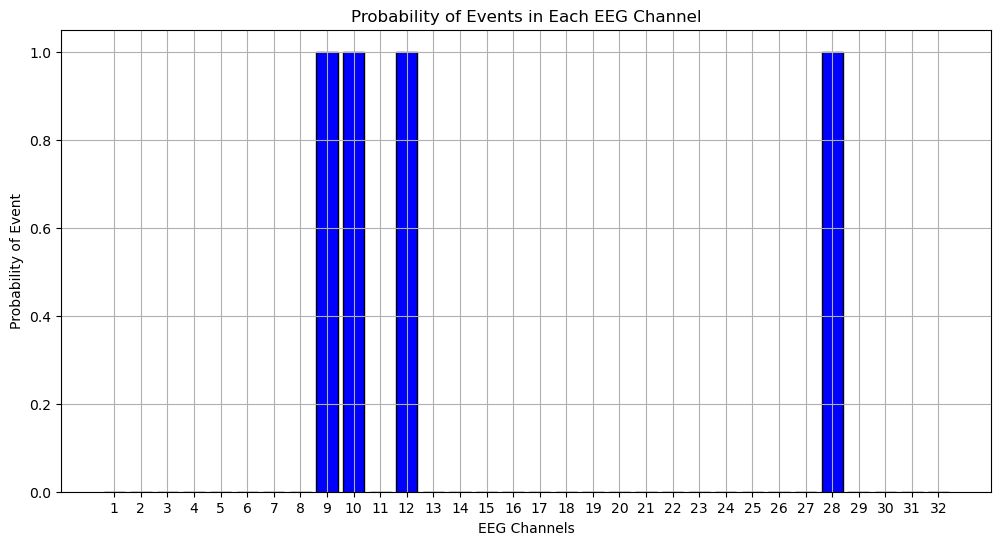

In [11]:
import numpy as np
import os

# Load EEG data
base_dir = '/home/vincent/MySSD/JupyterProjects/AAA_projects/UnlimitedResearchCooperative/Synthetic_Intelligence_Labs/EEG_Chaos_Kuramoto_Neural_Net'
EEG_data_path = os.path.join(base_dir, 'eeg_data_with_channels.npy')
EEG_data = np.load(EEG_data_path, allow_pickle=True)

sampling_rate = 1000  # Hz (adjust if necessary)
start_time, end_time = 814.571, 921.515  # Data without stimulation occurring
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)
EEG_data = EEG_data[start_index:end_index, :]

# Convert to binary using a threshold
threshold = np.mean(EEG_data) + np.std(EEG_data)
binary_EEG_data = (EEG_data > threshold).astype(int)

import matplotlib.pyplot as plt

# Calculate the probability of events (1s) in the binary EEG data
probabilities = np.mean(binary_EEG_data, axis=0)

# Plot the probabilities for each channel
plt.figure(figsize=(12, 6))
channels = np.arange(1, len(probabilities) + 1)
plt.bar(channels, probabilities, color='blue', edgecolor='black')
plt.xlabel('EEG Channels')
plt.ylabel('Probability of Event')
plt.title('Probability of Events in Each EEG Channel')
plt.xticks(channels)
plt.grid(True)
plt.show()

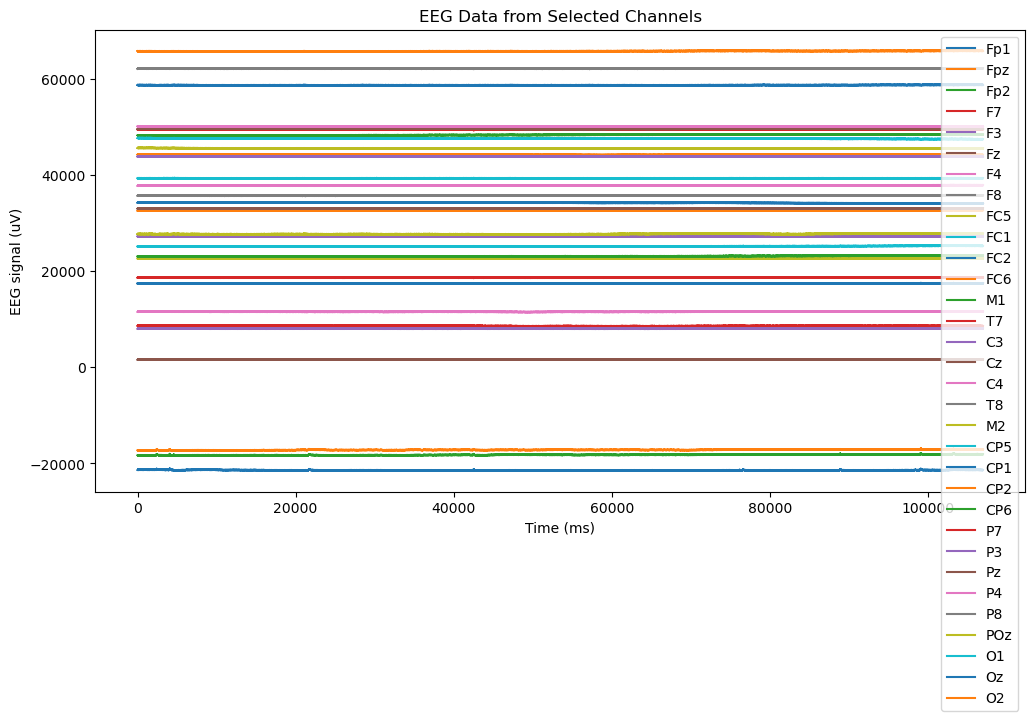

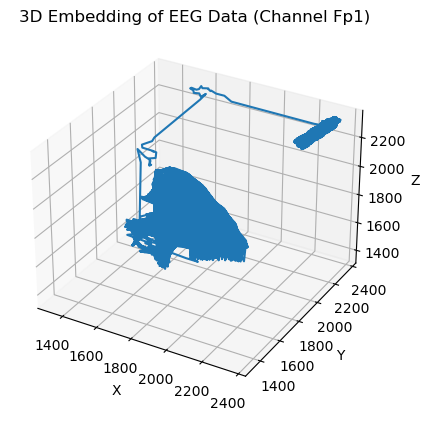

MemoryError: Unable to allocate 100. GiB for an array with shape (115906, 115906) and data type float64

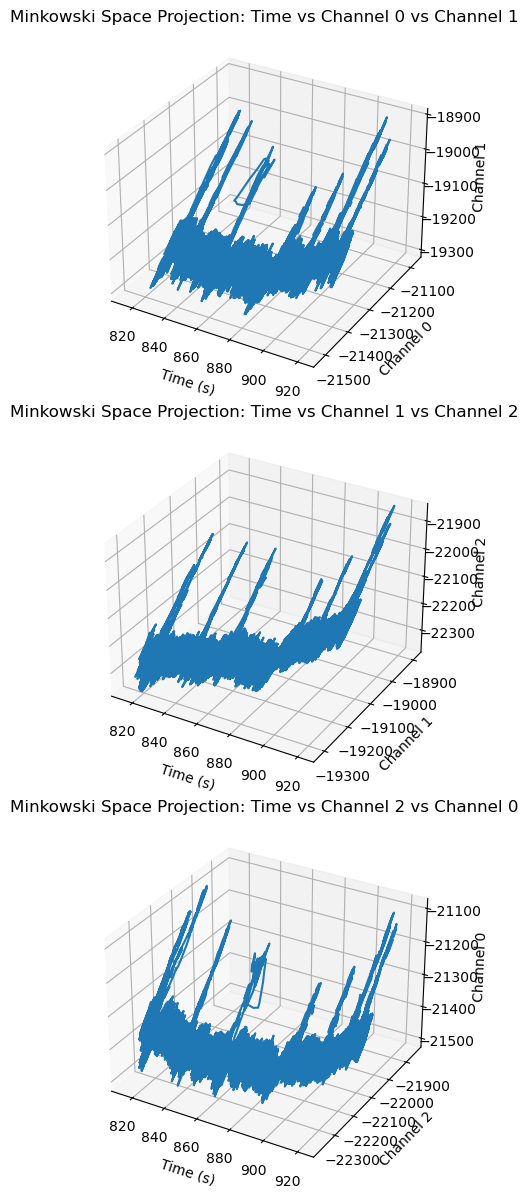

### Time dilation

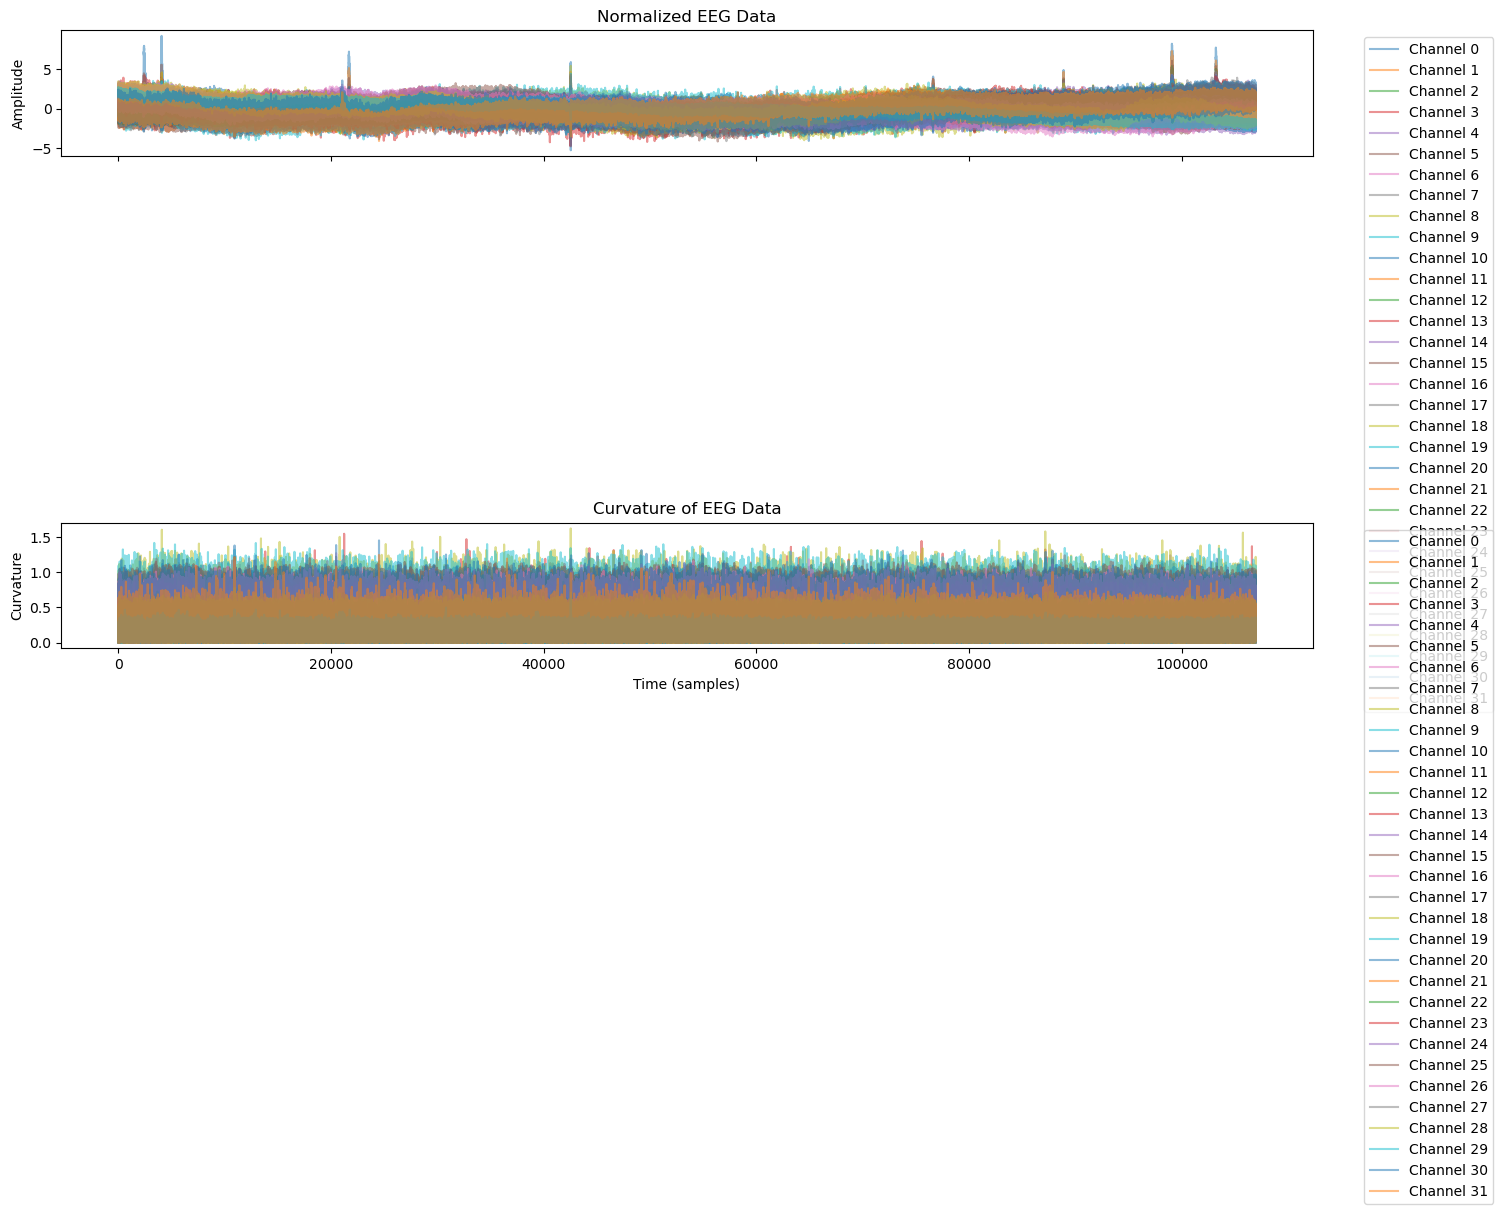

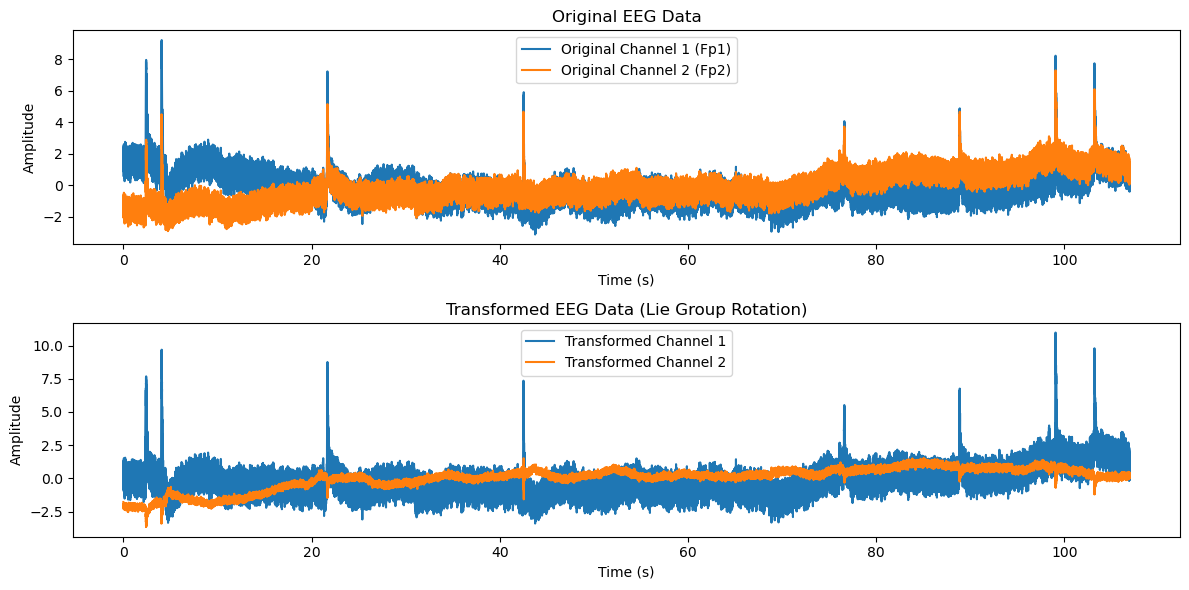

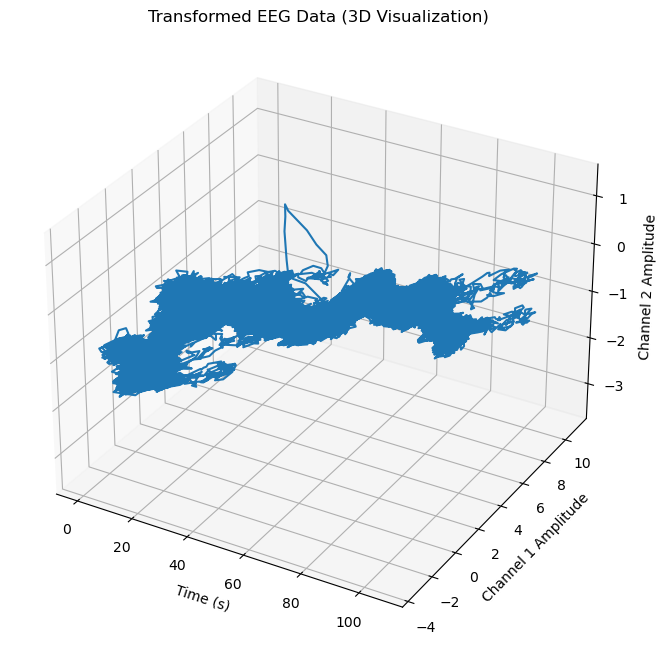

### Matrix Lie groups

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm, logm

# Define directories and load EEG data
base_dir = '/home/vincent/MySSD/JupyterProjects/AAA_projects/UnlimitedResearchCooperative/Synthetic_Intelligence_Labs/EEG_Chaos_Kuramoto_Neural_Net'
EEG_data_path = os.path.join(base_dir, 'eeg_data_with_channels.npy')
EEG_data = np.load(EEG_data_path, allow_pickle=True)

# Define parameters
sampling_rate = 1000  # Hz (adjust if necessary)
start_time, end_time = 814.571, 921.515  # Data without stimulation occurring
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

# Extract the relevant segment of the EEG data
EEG_data_segment = EEG_data[start_index:end_index, :]

# Define a function to transform EEG data using matrix Lie groups
def transform_eeg_data(data):
    transformed_data = []
    for sample in data:
        matrix = np.diag(sample)  # Convert each sample to a diagonal matrix (simple example)
        lie_group_matrix = expm(matrix)  # Map to Lie group
        transformed_sample = np.diag(logm(lie_group_matrix))  # Map back to Lie algebra
        transformed_data.append(transformed_sample)
    return np.array(transformed_data)

# Transform the EEG data
transformed_EEG_data = transform_eeg_data(EEG_data_segment)

# Plot the original and transformed EEG data
plt.figure(figsize=(14, 7))

plt.subplot(2, 1, 1)
plt.plot(EEG_data_segment[:, 0], label='Original EEG Channel 1')
plt.plot(EEG_data_segment[:, 1], label='Original EEG Channel 2')
plt.title('Original EEG Data')
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(transformed_EEG_data[:, 0], label='Transformed EEG Channel 1')
plt.plot(transformed_EEG_data[:, 1], label='Transformed EEG Channel 2')
plt.title('Transformed EEG Data using Matrix Lie Groups')
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude')
plt.legend()

plt.tight_layout()
plt.show()

/home/vincent/anaconda3/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:337: RuntimeWarning: overflow encountered in exp
  eA[ind] = np.diag(np.exp(np.diag(aw)))
/home/vincent/anaconda3/lib/python3.9/site-packages/scipy/linalg/_matfuncs_inv_ssq.py:827: LogmExactlySingularWarning: The logm input matrix is exactly singular.
  warnings.warn(exact_singularity_msg, LogmExactlySingularWarning)


KeyboardInterrupt: 

### Complex manifolds

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Define directories and load EEG data
base_dir = '/home/vincent/MySSD/JupyterProjects/AAA_projects/UnlimitedResearchCooperative/Synthetic_Intelligence_Labs/EEG_Chaos_Kuramoto_Neural_Net'
EEG_data_path = os.path.join(base_dir, 'eeg_data_with_channels.npy')
EEG_data = np.load(EEG_data_path, allow_pickle=True)

# Define sampling rate and time window
sampling_rate = 1000  # Hz (adjust if necessary)
start_time, end_time = 814.571, 921.515  # Data without stimulation occurring
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)
EEG_data = EEG_data[start_index:end_index, :]

# Embed the EEG data into a complex space
# Create complex-valued features by combining real and imaginary parts
complex_EEG_data = EEG_data[:, :16] + 1j * EEG_data[:, 16:32]

# Flatten the complex data
complex_EEG_flattened = complex_EEG_data.reshape(complex_EEG_data.shape[0], -1)

# Apply PCA to reduce dimensionality for t-SNE
pca = PCA(n_components=50)
pca_result = pca.fit_transform(complex_EEG_flattened)

# Apply t-SNE for visualization
tsne = TSNE(n_components=2, perplexity=30, n_iter=300)
tsne_result = tsne.fit_transform(pca_result)

# Plot the t-SNE results
plt.figure(figsize=(12, 8))
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=np.arange(tsne_result.shape[0]), cmap='viridis', s=5)
plt.colorbar()
plt.title('t-SNE of EEG Data Embedded in Complex Manifold')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()

RuntimeError: Failed to process string with tex because dvipng could not be found

<Figure size 1000x600 with 1 Axes>

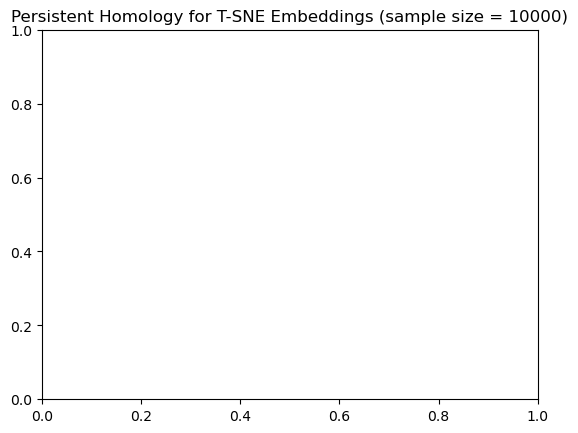

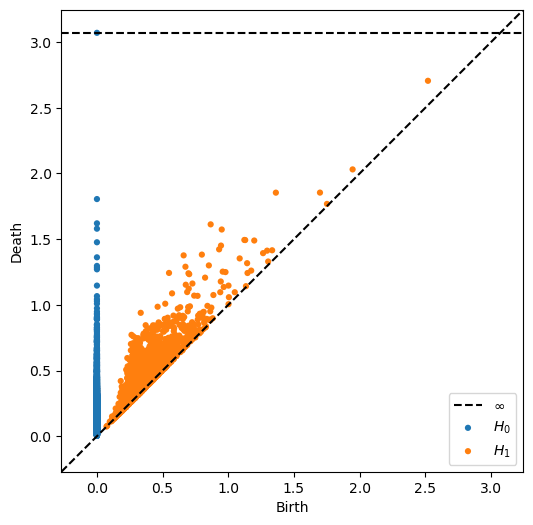

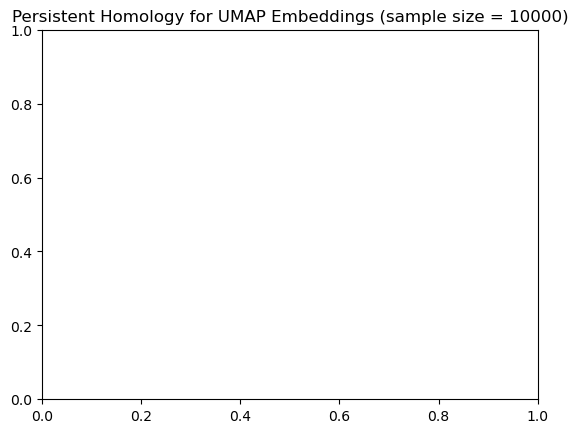

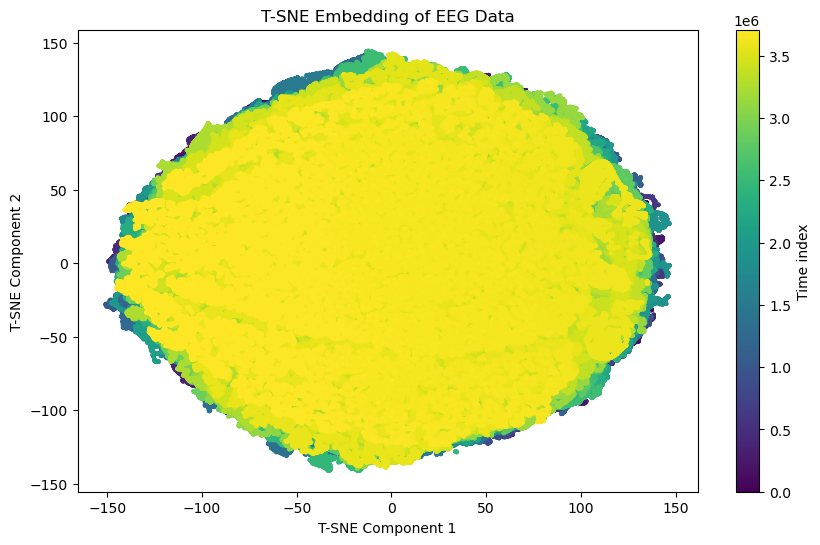

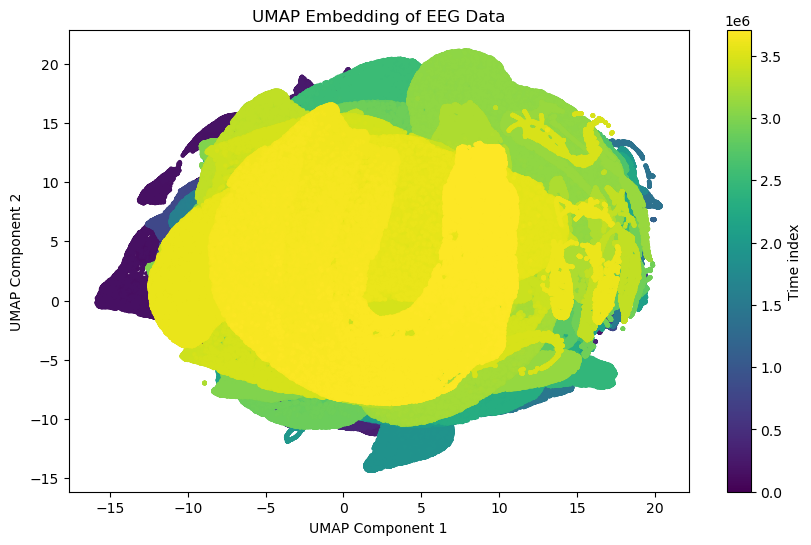

IndexError: Index out of range: a[2]

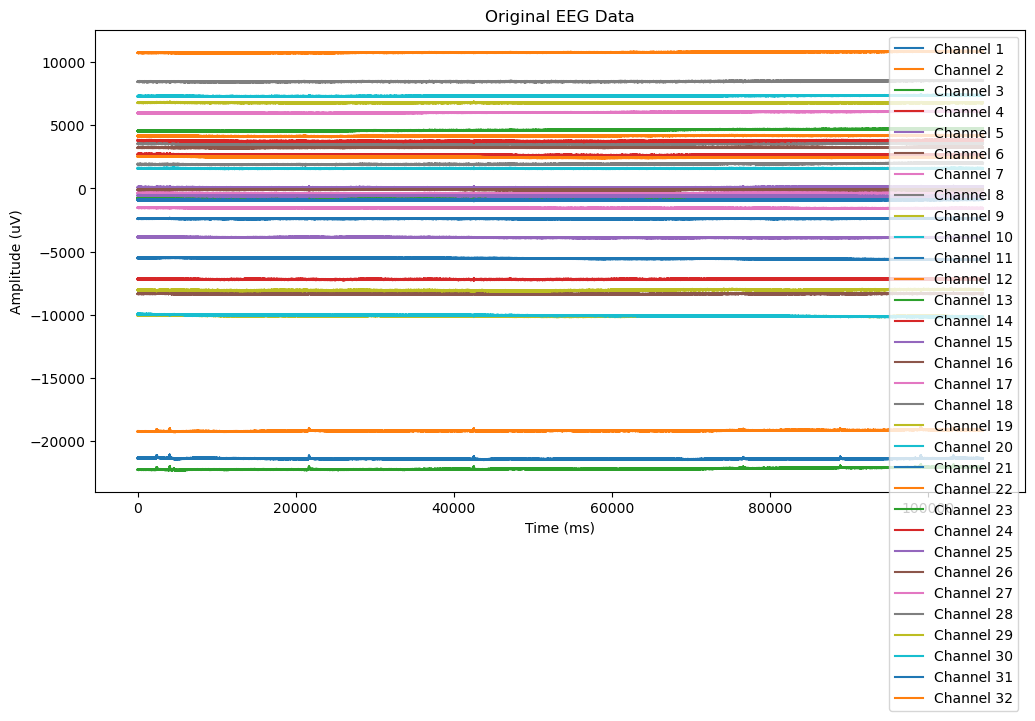

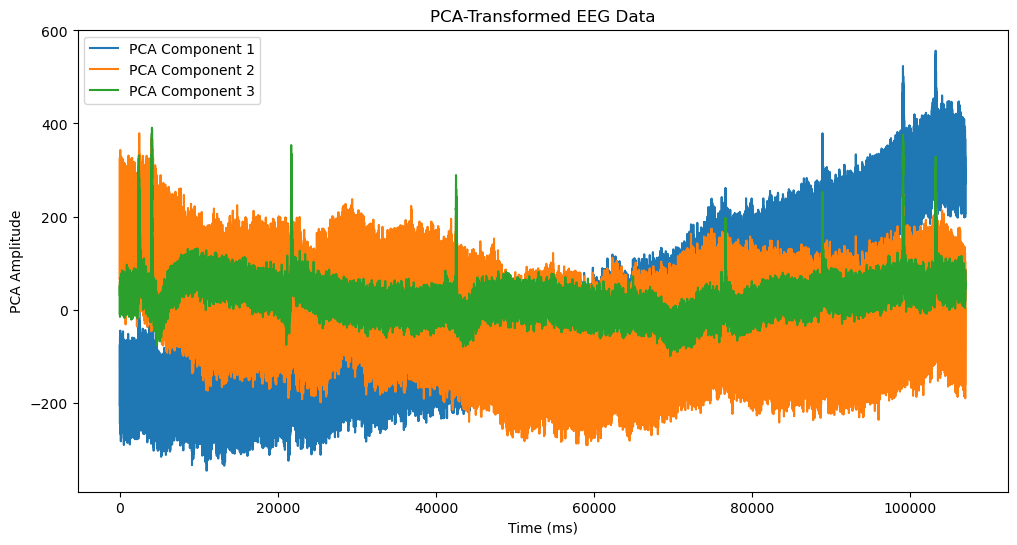

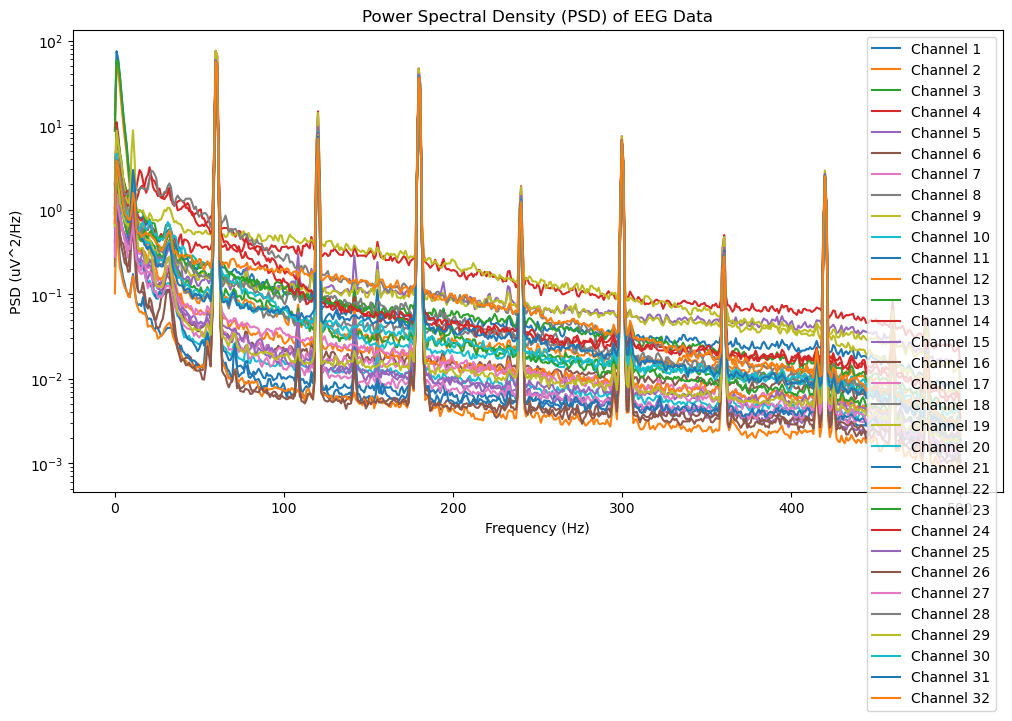

### Infinitesimal generators

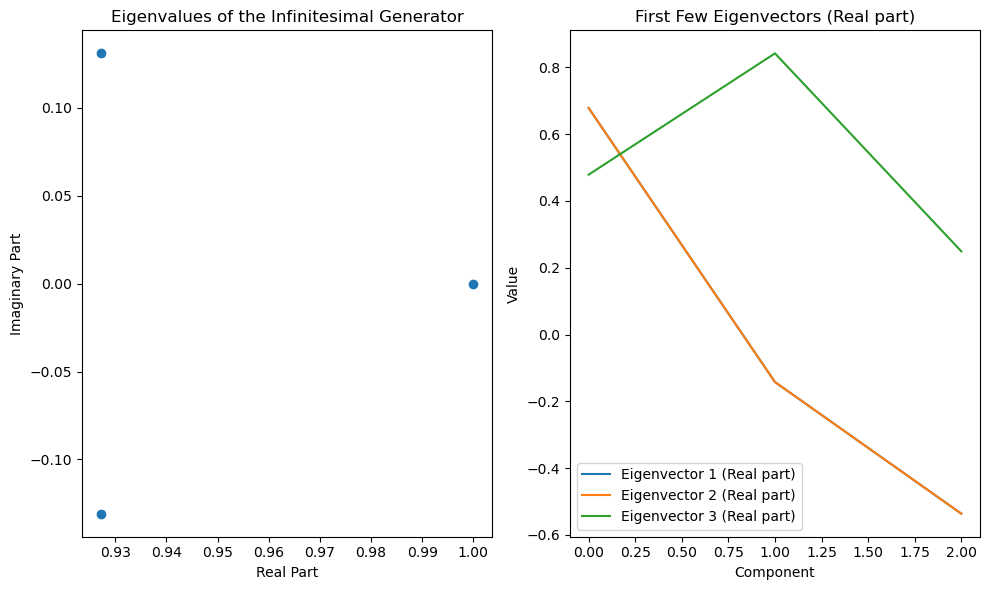

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.linalg import eig

# Define directories
base_dir = '/home/vincent/MySSD/JupyterProjects/AAA_projects/UnlimitedResearchCooperative/Synthetic_Intelligence_Labs/EEG_Chaos_Kuramoto_Neural_Net'
embedding_3d_dir = os.path.join(base_dir, '3dembedding_data')

# List all .npy files in the directory
file_paths = [os.path.join(embedding_3d_dir, file) for file in os.listdir(embedding_3d_dir) if file.endswith('.npy')]

# Load EEG data
EEG_data_path = os.path.join(base_dir, 'eeg_data_with_channels.npy')
EEG_data = np.load(EEG_data_path, allow_pickle=True)

# Sampling rate and time window
sampling_rate = 1000  # Hz (adjust if necessary)
start_time, end_time = 814.571, 921.515  # Data without stimulation occurring
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)
EEG_data = EEG_data[start_index:end_index, :]

# Load the 3D embedding data
embedding_data = []
for file_path in file_paths:
    embedding_data.append(np.load(file_path, allow_pickle=True))

embedding_data = np.concatenate(embedding_data, axis=0)

# Ensure embedding data matches the selected time window
embedding_data = embedding_data[start_index:end_index, :]

# Reshape if necessary (assuming embedding data is 3D)
time_series_length, embedding_dimension = embedding_data.shape

# Estimate infinitesimal generator using linear model (least squares)
X = embedding_data[:-1]
Y = embedding_data[1:]
A = np.linalg.lstsq(X, Y, rcond=None)[0]

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = eig(A)

# Plot results
plt.figure(figsize=(10, 6))

# Plot eigenvalues
plt.subplot(1, 2, 1)
plt.plot(eigenvalues.real, eigenvalues.imag, 'o')
plt.title('Eigenvalues of the Infinitesimal Generator')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')

# Plot first few eigenvectors
plt.subplot(1, 2, 2)
for i in range(3):  # Plot first 3 eigenvectors
    plt.plot(eigenvectors[:, i].real, label=f'Eigenvector {i+1} (Real part)')
plt.title('First Few Eigenvectors (Real part)')
plt.xlabel('Component')
plt.ylabel('Value')
plt.legend()

plt.tight_layout()
plt.show()

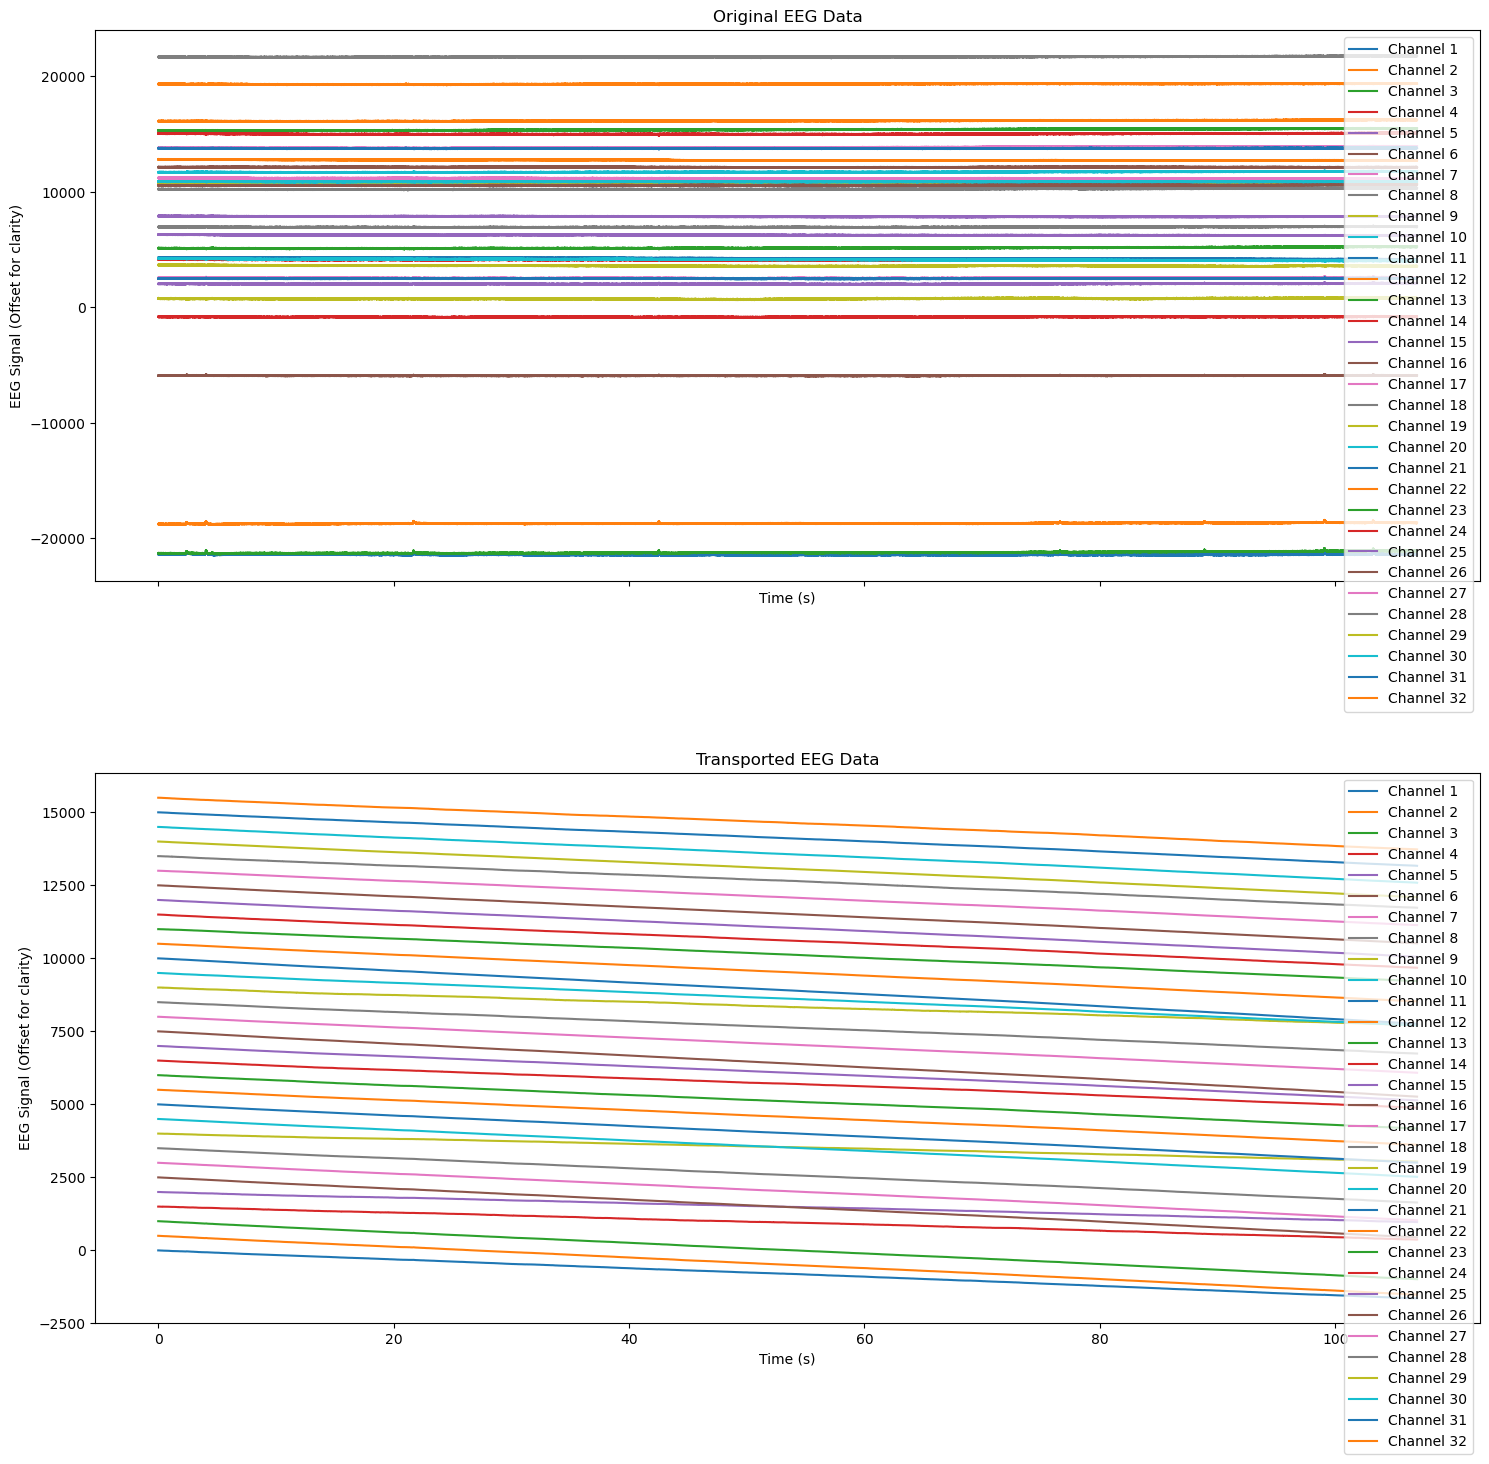

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define directories and load EEG data
base_dir = '/home/vincent/MySSD/JupyterProjects/AAA_projects/UnlimitedResearchCooperative/Synthetic_Intelligence_Labs/EEG_Chaos_Kuramoto_Neural_Net'
EEG_data_path = os.path.join(base_dir, 'eeg_data_with_channels.npy')
EEG_data = np.load(EEG_data_path, allow_pickle=True)

# Parameters
sampling_rate = 1000  # Hz
start_time, end_time = 814.571, 921.515  # Data without stimulation occurring
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)
EEG_data = EEG_data[start_index:end_index, :]

# Function to compute the parallel transport using Ehresmann connection concept
def parallel_transport(EEG_data):
    n_samples, n_channels = EEG_data.shape
    transported_data = np.zeros_like(EEG_data)
    
    for i in range(1, n_samples):
        # Compute the difference between consecutive time points
        delta = EEG_data[i] - EEG_data[i - 1]
        
        # Normalize the difference to get the direction of transport
        delta_norm = np.linalg.norm(delta)
        if delta_norm != 0:
            direction = delta / delta_norm
        else:
            direction = np.zeros_like(delta)
        
        # Transport the data
        transported_data[i] = transported_data[i - 1] + direction
    
    return transported_data

# Apply parallel transport to EEG data
transported_EEG_data = parallel_transport(EEG_data)

# Plot the results
def plot_EEG_data(original_data, transported_data):
    n_channels = original_data.shape[1]
    time = np.arange(original_data.shape[0]) / sampling_rate

    fig, axes = plt.subplots(2, 1, figsize=(15, 15), sharex=True)
    
    # Original EEG data
    for i in range(n_channels):
        axes[0].plot(time, original_data[:, i] + i * 500, label=f'Channel {i+1}')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('EEG Signal (Offset for clarity)')
    axes[0].set_title('Original EEG Data')
    axes[0].legend(loc='upper right')

    # Transported EEG data
    for i in range(n_channels):
        axes[1].plot(time, transported_data[:, i] + i * 500, label=f'Channel {i+1}')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('EEG Signal (Offset for clarity)')
    axes[1].set_title('Transported EEG Data')
    axes[1].legend(loc='upper right')

    plt.tight_layout()
    plt.show()

# Plot the EEG data
plot_EEG_data(EEG_data, transported_EEG_data)


In [8]:
import numpy as np
import os

base_dir = '/home/vincent/MySSD/JupyterProjects/AAA_projects/UnlimitedResearchCooperative/Synthetic_Intelligence_Labs/EEG_Chaos_Kuramoto_Neural_Net'
EEG_data_path = os.path.join(base_dir, 'eeg_data_with_channels.npy')
EEG_data = np.load(EEG_data_path, allow_pickle=True)

sampling_rate = 1000  # Hz
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)
EEG_data = EEG_data[start_index:end_index, :]

def covariant_derivative(EEG_data, sampling_rate):
    # Time derivative
    dE_dt = np.gradient(EEG_data, axis=0) * sampling_rate
    
    # Connection matrix (Gamma)
    # For simplicity, assume Gamma is zero or identity matrix
    # This can be adjusted based on specific relationships
    Gamma = np.zeros_like(EEG_data)
    
    # Covariant derivative
    nabla_E = dE_dt + np.tensordot(Gamma, EEG_data, axes=([1], [1]))
    
    return nabla_E

nabla_EEG = covariant_derivative(EEG_data, sampling_rate)


import matplotlib.pyplot as plt

# Compute the norm of the covariant derivative
norm_nabla_EEG = np.linalg.norm(nabla_EEG, axis=1)

# Plot the norm of the covariant derivative
plt.plot(norm_nabla_EEG)
plt.xlabel('Time (ms)')
plt.ylabel('Norm of Covariant Derivative')
plt.title('Covariant Derivative of EEG Signals')
plt.show()

MemoryError: Unable to allocate 85.2 GiB for an array with shape (106944, 106944) and data type float64